# **Importing Libraries**

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# **Data Preperation**

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


# **Model Architecture**

In [3]:
model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# **Training \& Evaluation**

In [5]:
model.fit(x_train, y_train, epochs=15, batch_size=32)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nOverall Test Accuracy: {test_acc * 100:.2f}%\n")

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 28ms/step - accuracy: 0.4065 - loss: 1.6382
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.6120 - loss: 1.1080
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 28ms/step - accuracy: 0.6657 - loss: 0.9555
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.7006 - loss: 0.8582
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.7300 - loss: 0.7681

Overall Test Accuracy: 68.97%



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


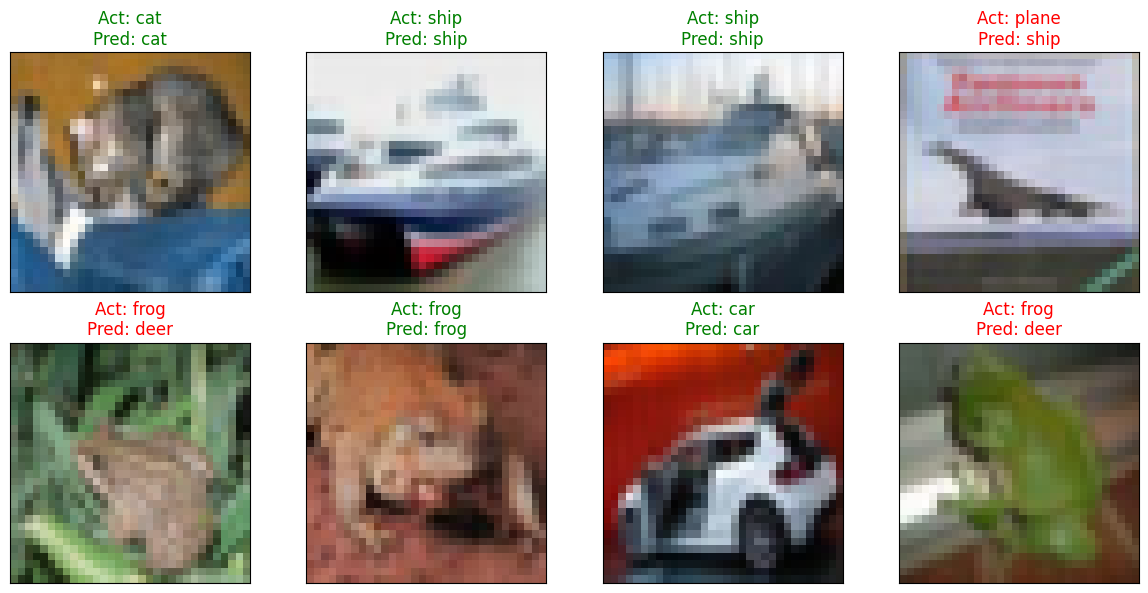

In [6]:
images = x_test[:8]
labels = y_test[:8].flatten()

outputs = model.predict(images)
predicted = np.argmax(outputs, axis=1)

fig = plt.figure(figsize=(12, 6))


for i in range(8):
    ax = fig.add_subplot(2, 4, i+1, xticks=[], yticks=[])
    plt.imshow(images[i])

    act_label = classes[labels[i]]
    pred_label = classes[predicted[i]]
    color = "green" if act_label == pred_label else "red"
    ax.set_title(f"Act: {act_label}\nPred: {pred_label}", color=color)

plt.tight_layout()
plt.show()